# Smart Power — Time-Aware Machine Learning

**Goal:** predict the next hour's Dutch electricity price using only information available at the current hour.

This notebook completes the ML cards: feature engineering, lag features, preprocessing pipeline, chronological train/test split, baseline, Linear Regression, Random Forest, Gradient Boosting, time-series cross-validation, hyperparameter tuning, evaluation, and feature importance.

> Why time-aware validation? Hourly prices are strongly autocorrelated. Randomly mixing past and future observations would not reproduce real forecasting conditions.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (12, 6), "figure.dpi": 120})
BLUE, ORANGE, GREEN, GREY = "#4C78A8", "#F58518", "#54A24B", "#9D9D9D"
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from database import get_mysql_engine

engine = get_mysql_engine(PROJECT_ROOT)
print("Connected to MySQL database: smart_power")

Connected to MySQL database: smart_power


## 1. Load and validate the hourly data

In [2]:
with engine.connect() as connection:
    df = pd.read_sql_query(
        "SELECT * FROM hourly_data ORDER BY timestamp_utc", connection
    )

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], errors="raise").dt.tz_localize("UTC")
assert not df["timestamp_utc"].duplicated().any(), "Duplicate timestamps found"
assert df.isna().sum().sum() == 0, "Unexpected missing values in source table"
assert df["renewable_share"].between(0, 1).all(), "Renewable share outside [0, 1]"
assert df["carbon_intensity_gco2_kwh"].ge(0).all(), "Negative carbon intensity"

# Reindex to the full UTC clock so lag/target rows never jump across Wattnet gaps.
full_hourly_index = pd.date_range(df["timestamp_utc"].min(), df["timestamp_utc"].max(), freq="h")
missing_source_hours = full_hourly_index.difference(df["timestamp_utc"])
df = (df.set_index("timestamp_utc").reindex(full_hourly_index)
        .rename_axis("timestamp_utc").reset_index())
df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

print(f"Validated source rows: {len(df) - len(missing_source_hours):,}")
print(f"Missing clock hours preserved as gaps: {len(missing_source_hours):,}")
print(f"UTC coverage: {df['timestamp_utc'].min()} to {df['timestamp_utc'].max()}")
print(f"Price lag-1 autocorrelation: {df['electricity_price'].autocorr(1):.3f}")

Validated source rows: 1,170
Missing clock hours preserved as gaps: 460
UTC coverage: 2026-05-28 00:00:00+00:00 to 2026-08-03 21:00:00+00:00
Price lag-1 autocorrelation: 0.920


## 2. Feature engineering without look-ahead leakage

At row `t`, the target is the price at `t+1`. Calendar features describe the target hour; price, carbon, energy, and weather features come from `t` or earlier. Rolling features are trailing only. Missing Wattnet hours are preserved on a complete UTC clock before shifts are calculated, so observations separated by a gap are never treated as consecutive hours. In production, current observations would be replaced by the latest measurements or forecasts available at prediction time.

In [3]:
target_local = df["timestamp_local"] + pd.Timedelta(hours=1)
df["target_timestamp"] = df["timestamp_utc"] + pd.Timedelta(hours=1)
df["target_price"] = df["electricity_price"].shift(-1)

# Cyclical calendar encoding keeps midnight next to 23:00 and Sunday next to Monday.
target_hour = target_local.dt.hour
target_day = target_local.dt.dayofweek
df["hour_sin"] = np.sin(2 * np.pi * target_hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * target_hour / 24)
df["day_sin"] = np.sin(2 * np.pi * target_day / 7)
df["day_cos"] = np.cos(2 * np.pi * target_day / 7)
df["is_weekend"] = (target_day >= 5).astype(int)

# At time t, the current price is lag 1 relative to the t+1 target.
df["price_lag_1"] = df["electricity_price"]
df["price_lag_24"] = df["electricity_price"].shift(23)
df["price_rolling_mean_24"] = df["electricity_price"].rolling(24).mean()
df["price_rolling_std_24"] = df["electricity_price"].rolling(24).std()
df["renewable_lag_1"] = df["renewable_share"]
df["renewable_lag_24"] = df["renewable_share"].shift(23)
df["carbon_lag_1"] = df["carbon_intensity_gco2_kwh"]
df["carbon_lag_24"] = df["carbon_intensity_gco2_kwh"].shift(23)

feature_columns = [
    "hour_sin", "hour_cos", "day_sin", "day_cos", "is_weekend",
    "price_lag_1", "price_lag_24", "price_rolling_mean_24", "price_rolling_std_24",
    "renewable_lag_1", "renewable_lag_24",
    "carbon_lag_1", "carbon_lag_24",
    "renewable_generation", "total_generation", "wind_speed", "solar_radiation",
]
model_df = df.dropna(subset=feature_columns + ["target_price"]).reset_index(drop=True)
X = model_df[feature_columns]
y = model_df["target_price"]
print(f"Model-ready rows: {len(model_df):,}; features: {len(feature_columns)}")

Model-ready rows: 1,050; features: 17


## 3. Chronological train/test split and baselines

The oldest 80% is used for training and the newest 20% is held out once for final evaluation. The test set is never used during tuning.

In [4]:
split_index = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_timestamps = model_df["target_timestamp"].iloc[split_index:]

assert X_train.index.max() < X_test.index.min()
print(f"Train: {len(X_train):,} rows | through {model_df['target_timestamp'].iloc[split_index - 1]}")
print(f"Test:  {len(X_test):,} rows | {test_timestamps.min()} to {test_timestamps.max()}")

def metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

results = []
results.append({"Model": "Mean baseline", **metrics(y_test, np.repeat(y_train.mean(), len(y_test)))})
results.append({"Model": "Persistence baseline (last price)", **metrics(y_test, X_test["price_lag_1"])})
pd.DataFrame(results).set_index("Model").style.format("{:.4f}")

Train: 840 rows | through 2026-07-24 03:00:00+00:00
Test:  210 rows | 2026-07-24 04:00:00+00:00 to 2026-08-03 21:00:00+00:00


,RMSE,MAE,R2
Model,,,
Mean baseline,0.0804,0.0710,-0.0369
Persistence baseline (last price),0.0314,0.0210,0.8420


## 4. Preprocessing pipeline and candidate models

In [5]:
preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), feature_columns),
])

candidate_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

selection_cv = TimeSeriesSplit(n_splits=4)
fitted_models = {}
for name, estimator in candidate_models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    cv_rmse = -cross_val_score(
        pipeline, X_train, y_train, cv=selection_cv,
        scoring="neg_root_mean_squared_error", n_jobs=1,
    ).mean()
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    fitted_models[name] = pipeline
    results.append({"Model": name, "CV_RMSE": cv_rmse, **metrics(y_test, prediction)})

results_df = pd.DataFrame(results).drop_duplicates("Model", keep="last").set_index("Model").sort_values("RMSE")
display(results_df.style.format("{:.4f}").highlight_min(subset=["CV_RMSE", "RMSE", "MAE"], color="#d8f3dc").highlight_max(subset=["R2"], color="#d8f3dc"))

,RMSE,MAE,R2,CV_RMSE
Model,,,,
Random Forest,0.0193,0.0131,0.9402,0.0237
Gradient Boosting,0.0195,0.0132,0.9393,0.0250
Linear Regression,0.0244,0.0176,0.9045,0.0277
Persistence baseline (last price),0.0314,0.0210,0.8420,nan
Mean baseline,0.0804,0.0710,-0.0369,nan


## 5. Time-series cross-validation and hyperparameter tuning

`TimeSeriesSplit` uses expanding training windows, so every validation fold occurs after its training fold.

In [6]:
tscv = TimeSeriesSplit(n_splits=4)
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
])
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3],
}
grid = GridSearchCV(
    gb_pipeline, param_grid=param_grid, cv=tscv,
    scoring="neg_root_mean_squared_error", n_jobs=1, return_train_score=False,
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
best_prediction = best_model.predict(X_test)
tuned_metrics = metrics(y_test, best_prediction)
print("Best parameters:", grid.best_params_)
print(f"Best CV RMSE: {-grid.best_score_:.4f}")
print("Held-out test:", {key: round(value, 4) for key, value in tuned_metrics.items()})

results_df.loc["Tuned Gradient Boosting"] = {"CV_RMSE": -grid.best_score_, **tuned_metrics}
results_df = results_df.sort_values("RMSE")
display(results_df.style.format("{:.4f}"))

Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200}
Best CV RMSE: 0.0241
Held-out test: {'RMSE': 0.0189, 'MAE': 0.0129, 'R2': 0.9425}


,RMSE,MAE,R2,CV_RMSE
Model,,,,
Tuned Gradient Boosting,0.0189,0.0129,0.9425,0.0241
Random Forest,0.0193,0.0131,0.9402,0.0237
Gradient Boosting,0.0195,0.0132,0.9393,0.0250
Linear Regression,0.0244,0.0176,0.9045,0.0277
Persistence baseline (last price),0.0314,0.0210,0.8420,nan
Mean baseline,0.0804,0.0710,-0.0369,nan


## 6. Forecast diagnostics

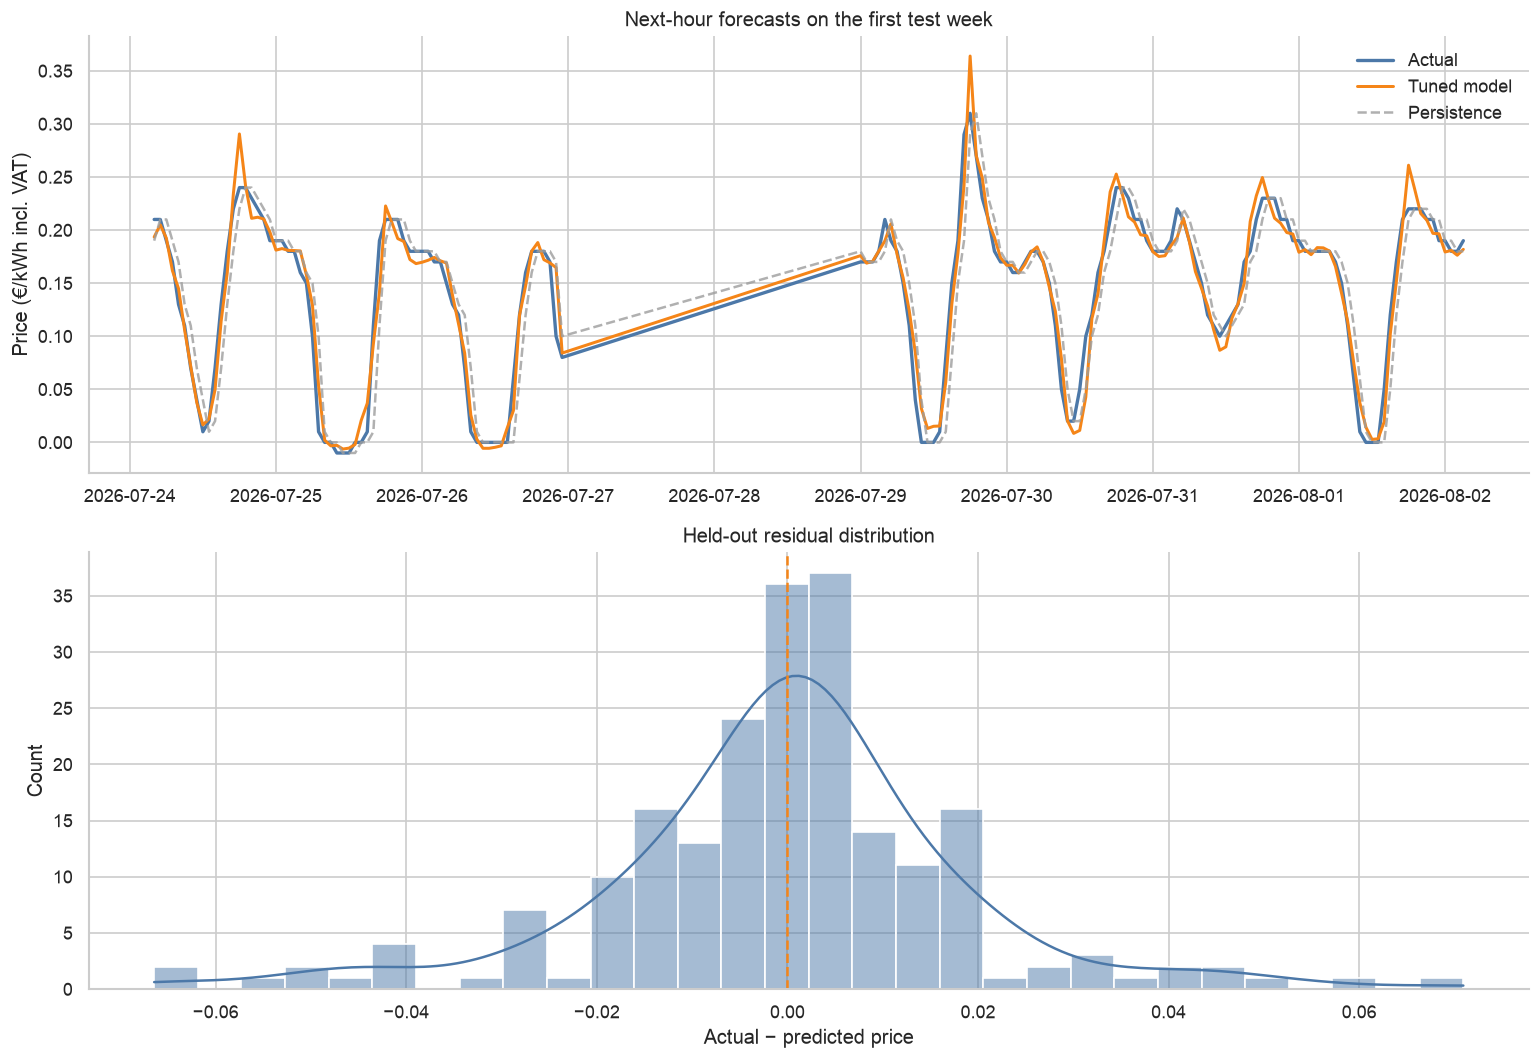

,count,mean,std,min,25%,50%,75%,max
actual,210.0,0.139714,0.079140,-0.010000,0.085000,0.170000,0.190000,0.310000
predicted,210.0,0.140173,0.079044,-0.006301,0.084244,0.168123,0.192798,0.363944
residual,210.0,-0.000459,0.018979,-0.066465,-0.008249,0.000297,0.007868,0.070927


In [7]:
comparison = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "actual": y_test.values,
    "predicted": best_prediction,
    "persistence": X_test["price_lag_1"].values,
})
comparison["residual"] = comparison["actual"] - comparison["predicted"]

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
week = comparison.head(24 * 7)
axes[0].plot(week["timestamp"], week["actual"], label="Actual", color=BLUE, linewidth=2)
axes[0].plot(week["timestamp"], week["predicted"], label="Tuned model", color=ORANGE, linewidth=1.8)
axes[0].plot(week["timestamp"], week["persistence"], label="Persistence", color=GREY, linestyle="--", alpha=0.8)
axes[0].set(title="Next-hour forecasts on the first test week", ylabel="Price (€/kWh incl. VAT)")
axes[0].legend(frameon=False)
sns.histplot(comparison["residual"], bins=30, kde=True, color=BLUE, ax=axes[1])
axes[1].axvline(0, color=ORANGE, linestyle="--")
axes[1].set(title="Held-out residual distribution", xlabel="Actual − predicted price")
sns.despine()
plt.tight_layout()
plt.show()
display(comparison[["actual", "predicted", "residual"]].describe().T)

## 7. Permutation feature importance

Permutation importance measures the increase in held-out RMSE after shuffling one feature. It is evaluated on unseen test data and is less biased toward continuous variables than tree impurity importance.

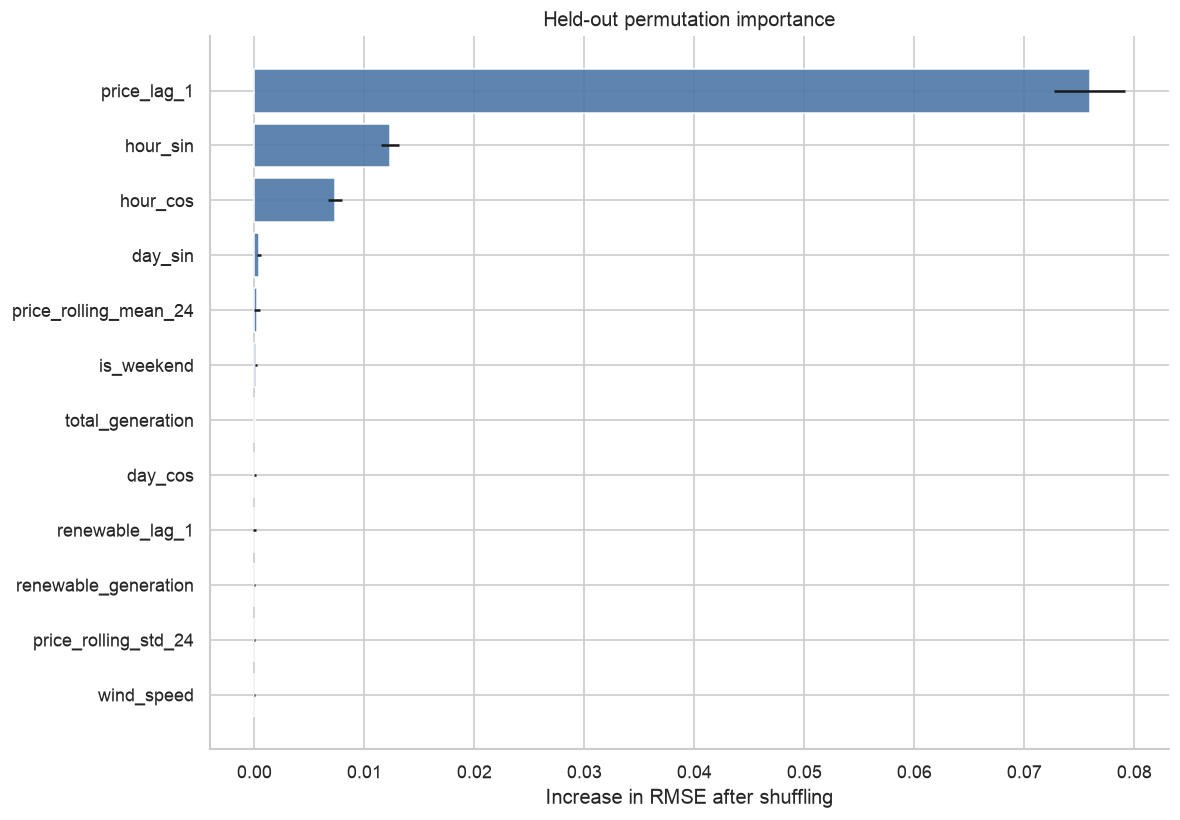

,feature,importance_mean,importance_std
5,price_lag_1,0.0759,0.0032
0,hour_sin,0.0123,0.0008
1,hour_cos,0.0073,0.0007
2,day_sin,0.0004,0.0002
7,price_rolling_mean_24,0.0002,0.0002
4,is_weekend,0.0001,0.0000
14,total_generation,0.0001,0.0000
3,day_cos,0.0000,0.0001
9,renewable_lag_1,0.0000,0.0001
13,renewable_generation,-0.0000,0.0001


In [8]:
importance_result = permutation_importance(
    best_model, X_test, y_test, scoring="neg_root_mean_squared_error",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=1,
)
importance = (pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std,
}).sort_values("importance_mean", ascending=False))

top = importance.head(12).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color=BLUE, alpha=0.9)
ax.set(title="Held-out permutation importance", xlabel="Increase in RMSE after shuffling", ylabel="")
sns.despine()
plt.tight_layout()
plt.show()
display(importance.head(12).style.format({"importance_mean": "{:.4f}", "importance_std": "{:.4f}"}))
engine.dispose()


## 8. Conclusion and limitations

The tuned Gradient Boosting model is the final candidate because it improves on the persistence baseline on the chronological held-out period. The model predicts **one hour ahead**; it is not evidence that any feature causes electricity prices.

Limitations:
- The dataset covers only about 68 late-spring/summer days, so winter performance is unknown.
- ENTSO-E generation, Wattnet carbon intensity, and weather values used here are current observations. A deployed forecast should use only values or forecasts available at prediction time.
- Only Wattnet observations marked `valid=true` and `zone_status=complete` are used; excluded or missing hours reduce the model-ready sample.
- Extreme price spikes are rare and may be harder to predict than normal hours.
- Performance should be re-evaluated after collecting a full year of data.